In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

In [8]:
file_path = 'Country-data.csv'

In [ ]:
from kagglehub import KaggleDatasetAdapter

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "rohan0301/unsupervised-learning-on-country-data",
  file_path,
)
print("First 5 records:", df.head())

/tmp/ipykernel_22763/1701591076.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records:                country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


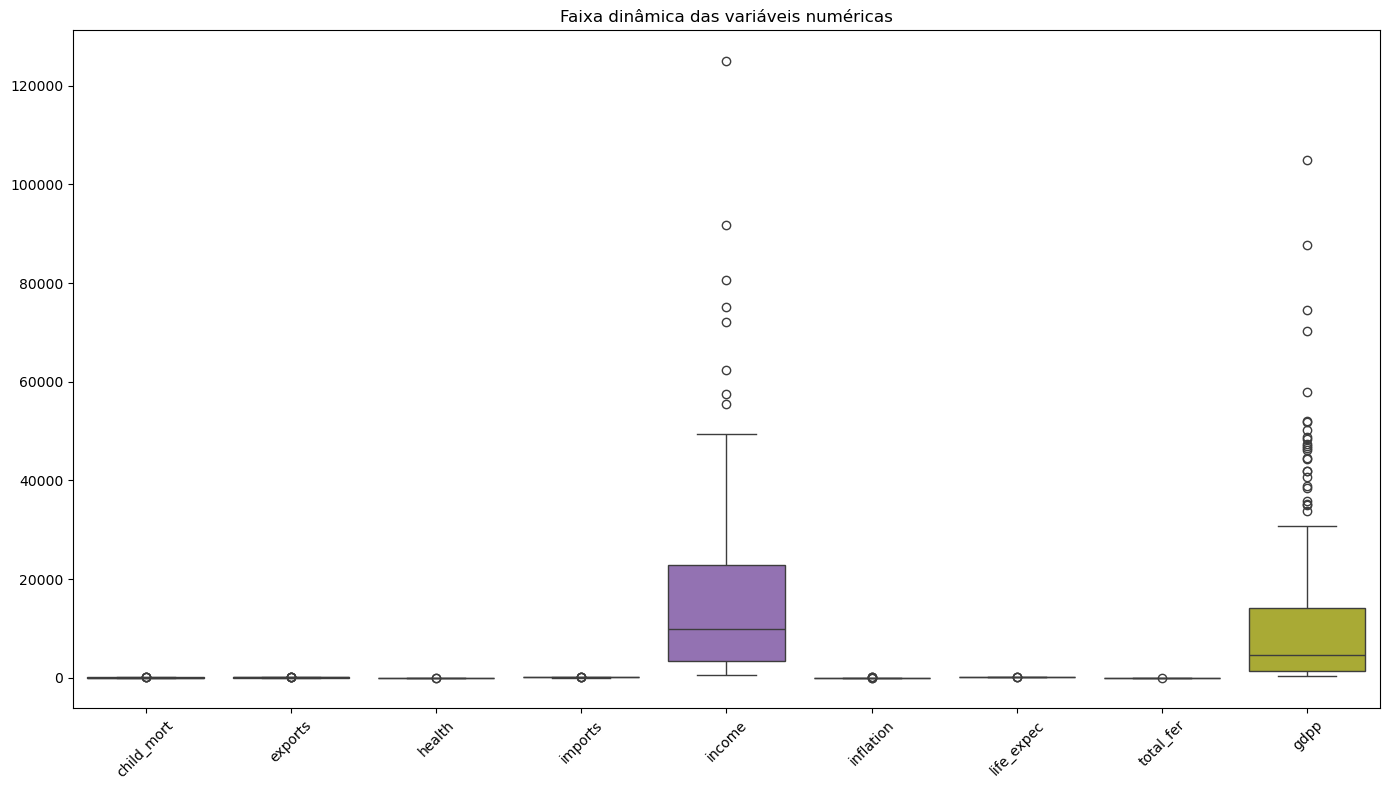

In [19]:
numeric_cols = df.columns.drop('country')

plt.figure(figsize=(14, 8))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.title('Faixa dinâmica das variáveis numéricas')
plt.tight_layout()
plt.show()

In [21]:
from sklearn.preprocessing import StandardScaler

X = df.drop('country', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print(X_scaled_df.head())

   child_mort   exports    health   imports    income  inflation  life_expec  \
0    1.291532 -1.138280  0.279088 -0.082455 -0.808245   0.157336   -1.619092   
1   -0.538949 -0.479658 -0.097016  0.070837 -0.375369  -0.312347    0.647866   
2   -0.272833 -0.099122 -0.966073 -0.641762 -0.220844   0.789274    0.670423   
3    2.007808  0.775381 -1.448071 -0.165315 -0.585043   1.387054   -1.179234   
4   -0.695634  0.160668 -0.286894  0.497568  0.101732  -0.601749    0.704258   

   total_fer      gdpp  
0   1.902882 -0.679180  
1  -0.859973 -0.485623  
2  -0.038404 -0.465376  
3   2.128151 -0.516268  
4  -0.541946 -0.041817  


In [58]:
from sklearn.cluster import KMeans
country_data = KMeans(n_clusters=3, random_state=42).fit(X_scaled_df.iloc[:, 0:])
centroids = country_data.cluster_centers_
country_data

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [51]:
labels = X_scaled_df['cluster'] = country_data.labels_
X_scaled_df.head(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180,2
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623,0


In [52]:
X_scaled_df['cluster'].value_counts()

cluster
0    86
2    45
1    36
Name: count, dtype: int64

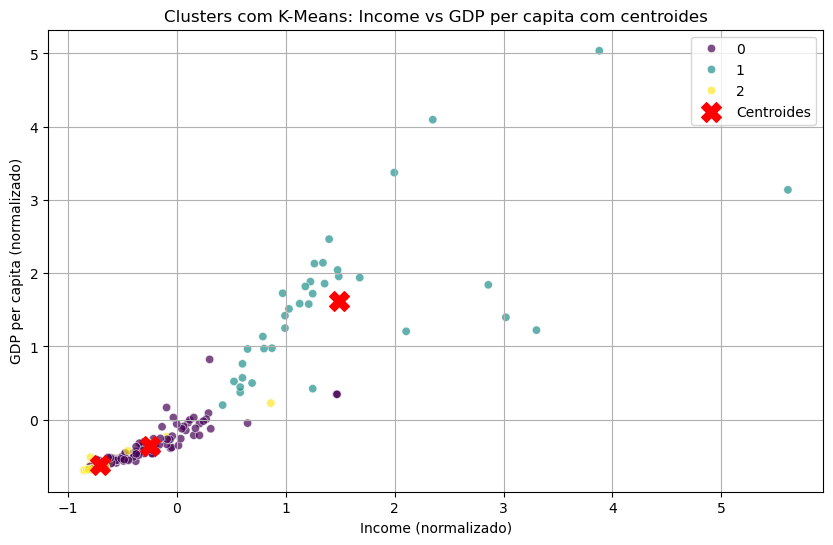

In [59]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_scaled_df['income'],
    y=X_scaled_df['gdpp'],
    hue=X_scaled_df['cluster'],
    palette='viridis',
    alpha=0.7
)

plt.scatter(
    centroids[:, X.columns.get_loc('income')],
    centroids[:, X.columns.get_loc('gdpp')],
    c='red',
    s=200,
    marker='X',
    label='Centroides'
)

plt.title('Clusters com K-Means: Income vs GDP per capita com centroides')
plt.xlabel('Income (normalizado)')
plt.ylabel('GDP per capita (normalizado)')
plt.legend()
plt.grid(True)
plt.show()

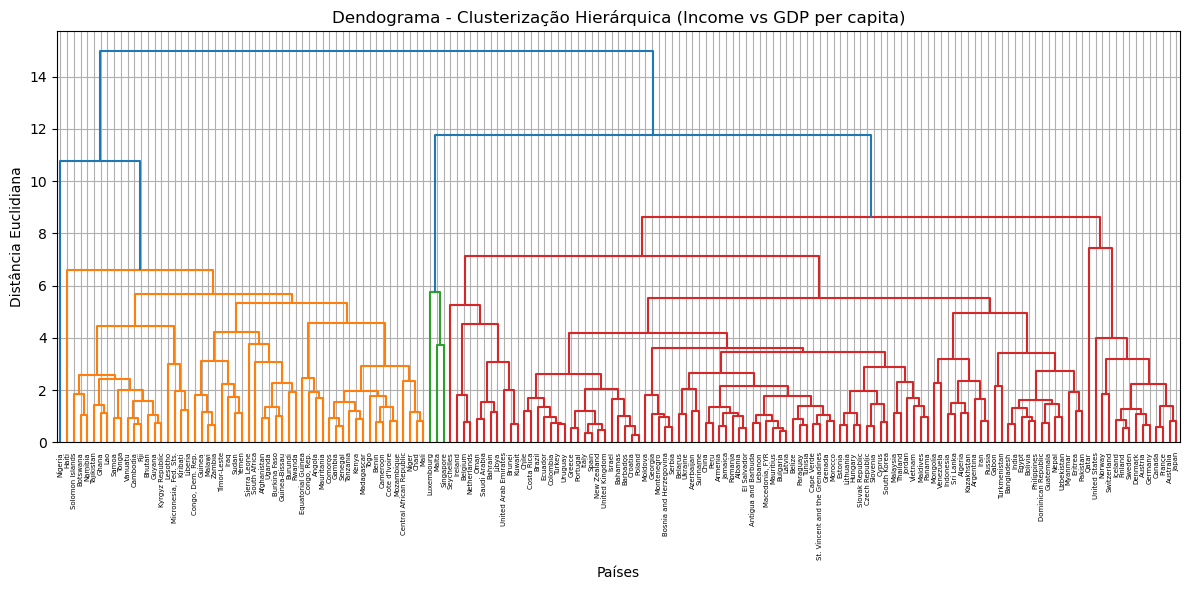

In [62]:
import scipy.cluster.hierarchy as sch
linkage_matrix = sch.linkage(X_scaled, method='complete', metric='euclidean')

plt.figure(figsize=(12, 6))
sch.dendrogram(linkage_matrix, labels=df['country'].values, leaf_rotation=90)
plt.title('Dendograma - Clusterização Hierárquica (Income vs GDP per capita)')
plt.xlabel('Países')
plt.ylabel('Distância Euclidiana')
plt.tight_layout()
plt.grid(True)
plt.show()